<a href="https://colab.research.google.com/github/sahelsepehri/diabetes-prediction-pima/blob/main/Diabetes-Prediction-Pima-Indians.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction – Pima Indians Dataset

**Goal**:

Predict whether a patient has diabetes (Outcome = 1) or not (Outcome = 0) using simple clinical data.

**Dataset**  
Pima Indians Diabetes Database (from UCI):  
- 768 samples  
- 8 features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age  
- Binary target: 0 = No Diabetes, 1 = Diabetes

**Models**  
- Random Forest Classifier  
- Logistic Regression (as baseline)

**Skills**  
- Data cleaning & handling invalid zeros  
- Visualization with Seaborn & Matplotlib  
- Model training, evaluation & comparison  
- Personal interpretation of results

**Note**  
This is my self-taught project to apply machine learning to real medical data. All visualizations, interpretations, and code changes are my own work.

# Step 1
## Import Required Libraries


In [131]:
# Import libraries for data handling, visualization, modeling, and evaluation
import numpy as np                  # Numerical operations
import pandas as pd                 # Data manipulation & DataFrames
import matplotlib.pyplot as plt     # Basic plotting
import seaborn as sns               # Beautiful statistical plots

from sklearn.model_selection import train_test_split  # Split data
from sklearn.preprocessing import StandardScaler      # Scale features
from sklearn.ensemble import RandomForestClassifier   # Main model
from sklearn.linear_model import LogisticRegression   # Simple baseline model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Evaluation metrics

# Set plot style for clean look
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


I use pandas and numpy for data, seaborn and matplotlib for plots, and scikit-learn for modeling. These are standard tools in machine learning projects.

---











#Step 2
##Load the dataset & define columns


In [132]:
# Load the dataset from a public URL (Pima Indians Diabetes Database)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, header=None, names=columns)  # No header in the CSV, so assign column names



# Step 3
## Data Inspection

### 1. Check number of rows and columns using df.shape:

In [133]:

print("Dataset shape:", df.shape)


Dataset shape: (768, 9)


This dataset has 768 samples and 9 columns (8 features + target)






### 2. The first 5 rows to understand the structure using df.head() :

In [134]:
print("\nFirst 5 rows:\n", df.head())  # Preview the data


First 5 rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


### 3. Check Data Types & Missing Values  Using info():


In [135]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


The data contains several biological features and a target variable (Outcome)

### 4. Proportion of Classes (Imbalance Check)

In [136]:
print("\nClass distribution:", df['Outcome'].value_counts(normalize=True).round(3))



Class distribution: Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


The dataset is imbalanced:

Class distribution shows that there are more non-diabetic individuals (Outcome=0) than diabetic ones (Outcome=1).


---



### 5. Summary Statistics of Dataset Using df.describe()

In [137]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


* This table displays some statistical operations like count, mean, median(50%),  min, max, standard deviation, Q1(25%), and Q3(75%) for each features.

* Some features contain '0' values, such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI that are physiologically and medically impossible, which requires data cleaning.


# Step 4
## Data Cleaning



Replacing zero values with NaN & fill them with median.

In [138]:
# Identify columns where zero values are invalid (medically impossible)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace invalid zeros with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# Fill NaN values with column medians (robust to outliers)
df.fillna(df.median(), inplace=True)

# Verify no missing values remain
print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


 I considered '0' values as a missing values and filled them with the median of columns.


---



 Now, the data is clean and ready for more analysis :


# Step 5
## Data Splitting & Scaling


1. Separate features and target
2. Split data into train/test sets
3. Scale features for better model performance




In [139]:
# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)  # All columns except Outcome
y = df['Outcome']  # Target

# Split into training and testing sets (70/30 split, stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # keep class balance in train/test
print("Data split successfully!")

# Scale features to standardize (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform train data
X_test_scaled = scaler.transform(X_test)  # Transform test data (no fit to avoid data leakage)

print("Train shape:", X_train.shape)  # Verify split sizes
print("Test shape:", X_test.shape)






Data split successfully!
Train shape: (537, 8)
Test shape: (231, 8)


* I split data into train (70%) and test (30%) sets.  
* I scale features because many ML models (especially SVM) are sensitive to scale.

* Scaling equals features like Age & BMI that have different scale. This improve models like Logistic Regression



---



# Step 6


## Model Selection Strategy
I decided to compare two different approaches:

1. Random Forest: To capture non-linear patterns and identify which biological factors (like Glucose) are most important for prediction.
2. Logistic Regression: As a simple baseline model for comparison.

## 1. Random Forest

* Training model
* Preddiction
* Evaluation

In [140]:
# Initialize Random Forest classifier with balanced weights for class imbalance
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model on scaled training data
rf.fit(X_train_scaled, y_train)

# Predict on test data
rf_pred = rf.predict(X_test_scaled)

# Evaluate
print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7532

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82       150
           1       0.69      0.53      0.60        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.75      0.75      0.74       231



* The accuracy is about 75% which is standard for this dataset.
* "class_weight" manage imbalance


---




## 2. Logistic Regression


* Training model
* Preddiction
* Evaluation

In [141]:
# Initialize Logistic Regression as a baseline model
lr = LogisticRegression(random_state=42)

# Train on scaled training data
lr.fit(X_train_scaled, y_train)

# Predict on test data
lr_pred = lr.predict(X_test_scaled)

# Evaluate
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.7446

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.86      0.81       150
           1       0.67      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.70      0.70       231
weighted avg       0.74      0.74      0.74       231



* The accuracy score is like RandomForest but simpler
* This model is linear & may not capture non-linear connection like BMI & Age very efficiently


---



# Step 7
## Data Visualizaton






## 1. Confusion Matrix Plot For Random Forest

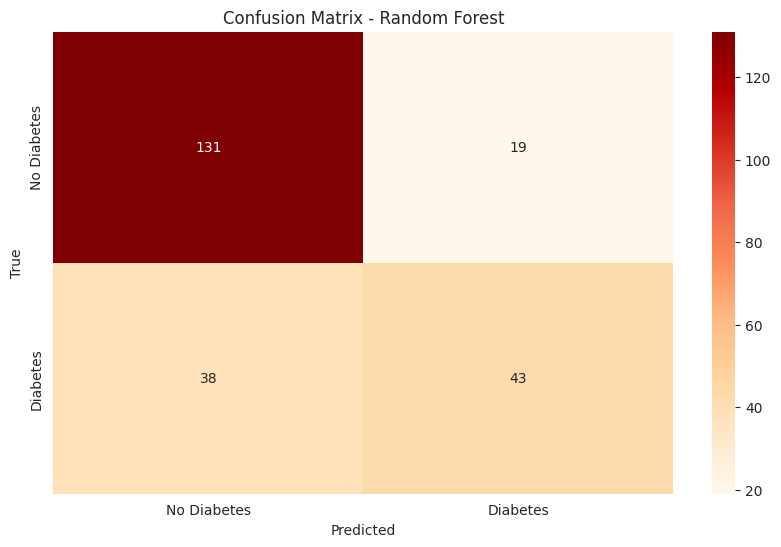

In [142]:
# Compute confusion matrix for Random Forest predictions
cm = confusion_matrix(y_test, rf_pred)

# Plot as heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('diabetes_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

* The metrics shows that false negative is low which is essential for medicine  because we do not miss the diabetes diagnosis.
* false positive may be because of imbalance.


---



##2. Bar Plot for Feature Importance


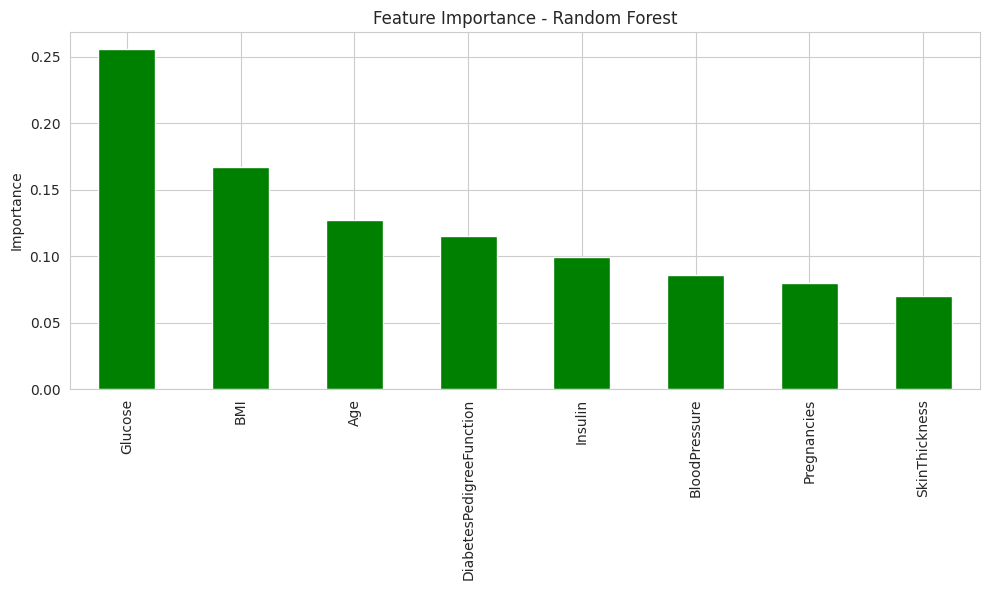

Top features:
Glucose                     0.255458
BMI                         0.166640
Age                         0.127405
DiabetesPedigreeFunction    0.115176
Insulin                     0.099636
BloodPressure               0.085494
Pregnancies                 0.080076
SkinThickness               0.070115
dtype: float64


In [143]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='green')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('diabetes_feature_importance.png', dpi=150)
plt.show()

print("Top features:")
print(importances.head(8))

Top features are Glucose, BMI, and Age; which are clinically meaningful.


---



## 3. Correlation Heatmap plot for Biological features

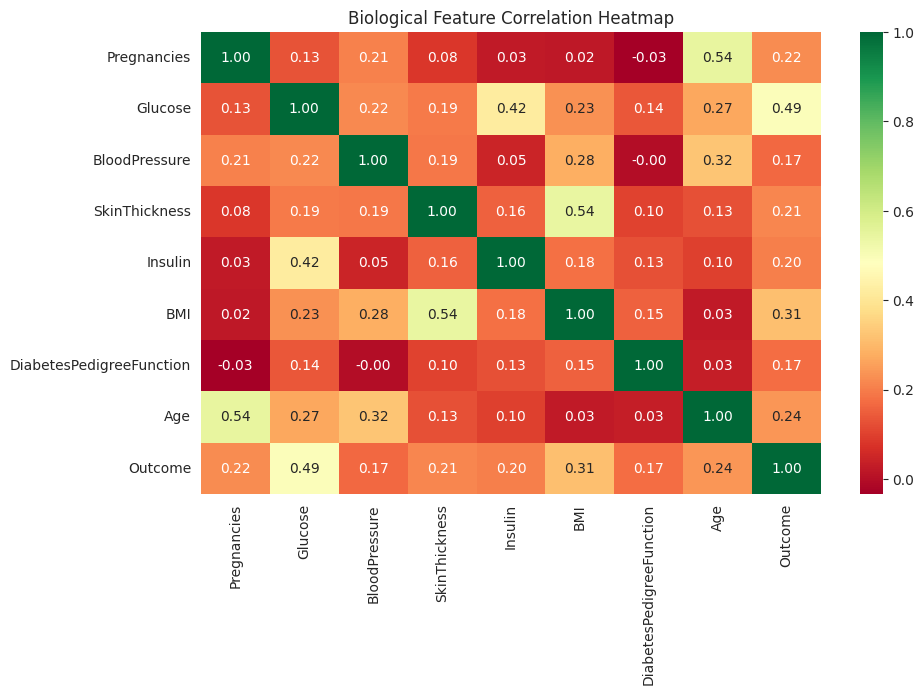

In [127]:
# Create correlation matrix for all features including Outcome
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Biological Feature Correlation Heatmap')
plt.show()

* Glucose has the most correlation with Outcome (0.49) that it makes sense in clinical terms
* BMI(0.31) & Age(0.24) are also important.


---



## 4. Scatter Plot for seeing how Age and Glucose are related to Diabetes


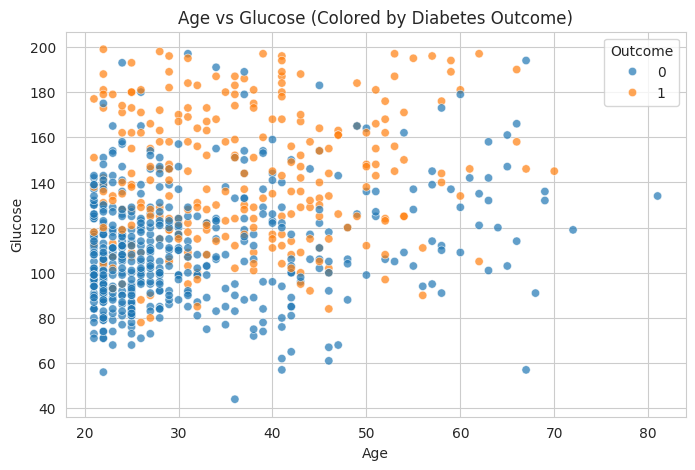

In [128]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome', alpha=0.7)
plt.title('Age vs Glucose (Colored by Diabetes Outcome)')
plt.show()

## 5. Histogram Plot of Glucose levels

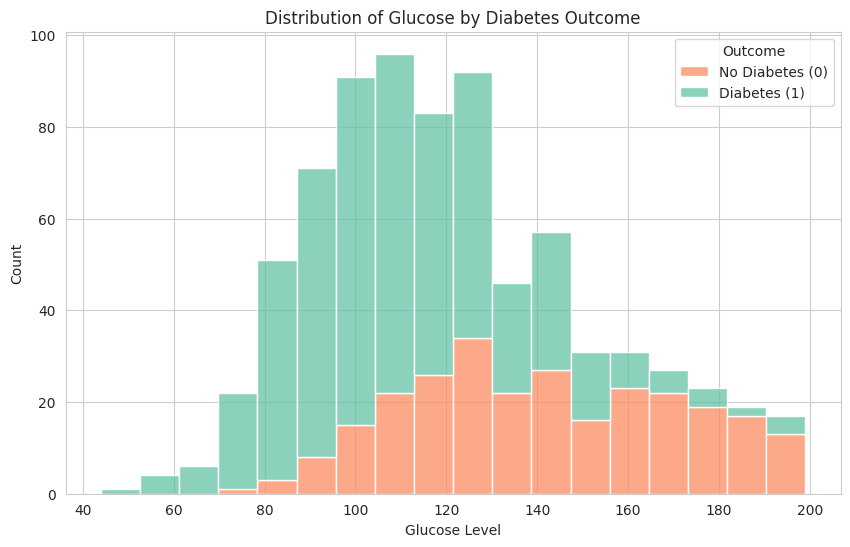

In [129]:
# Histogram of Glucose levels by diabetes status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Glucose', hue='Outcome', multiple='stack', palette='Set2')
plt.title('Distribution of Glucose by Diabetes Outcome')
plt.xlabel('Glucose Level')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['No Diabetes (0)', 'Diabetes (1)'])
plt.show()

Patients with diabetes (1) tend to have higher Glucose levels. This plot shows why Glucose is one of the most important features in the model.


---



## 6. Boxplot of BMI

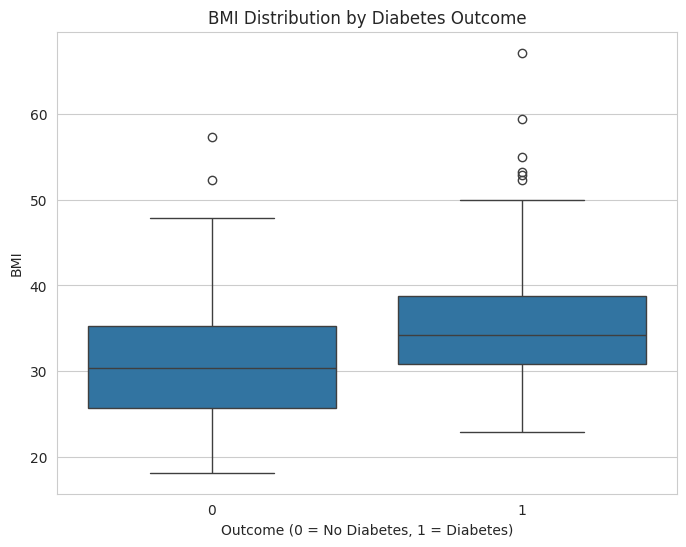

In [130]:
# Boxplot of BMI by diabetes status
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title('BMI Distribution by Diabetes Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('BMI')
plt.show()

Higher BMI values are more common in the diabetes group (1). This matches medical knowledge that obesity is a risk factor for diabetes.


---



# Step 8
## Final Summary & Interpretation  

We trained Random Forest and Logistic Regression on the Pima Indians Diabetes dataset.  
Accuracy ~75–80% (typical for this dataset due to noise and small size).  
Top features: Glucose, BMI, Age ; which are clinically meaningful.  

### What I Learned  
- Data cleaning is crucial in medical datasets (handling invalid zeros).  
- Visualizations like heatmaps help interpret biological relationships.  
- For better accuracy, we could use advanced techniques like feature engineering or ensemble methods.  

### Conclusion  
This project shows how simple ML can predict diabetes risk using basic clinical data. As a biology grad, it bridges my knowledge with computational tools. Future work: Test on larger datasets or add more features like genetics.


---



### What I Learned & Personal Thoughts
This project taught me that even with small and noisy medical data, simple machine learning can give useful predictions.  
It showed me how Glucose and BMI are key factors in diabetes ; something I learned from my biology background.  
Doing this project myself (with self-study) gave me confidence that I can learn and apply computational tools to real problems.

Future work: Try feature engineering (e.g., Glucose/BMI ratio) or test on larger datasets.


---



## References
- Pima Indians Diabetes Dataset: UCI Machine Learning Repository  
  https://archive.ics.uci.edu/dataset/34/diabetes

- Scikit-learn Documentation:  
  https://scikit-learn.org/stable/

- Seaborn Visualization Library:  
  https://seaborn.pydata.org/

- Pandas User Guide:  
  https://pandas.pydata.org/docs/